# GoodCredit Credit Risk Analysis

#### Predicting Customer Credit Default Risk Using SQL, Python, Machine Learning, and Power BI



# Project Overview

Credit risk assessment is one of the most critical functions in the banking and financial services industry. Financial institutions process thousands of loan and credit applications every day, making it essential to identify customers who are likely to default on their financial obligations.

This project focuses on analyzing customer demographic information, account history, and credit enquiry behavior to identify patterns associated with loan default. Using SQL for data preparation and Python for exploratory data analysis and machine learning, the project develops a predictive model that classifies customers into good or bad credit risk categories.

The objective is to support data-driven lending decisions, reduce financial losses, and improve overall portfolio quality.

# Business Problem

Banks and financial institutions face significant financial losses when customers fail to repay their loans or credit obligations. Incorrect credit approval decisions increase default rates, while overly strict approval policies may result in the loss of valuable customers.

Traditional credit evaluation methods often rely on limited rules and manual assessment, making it difficult to identify high-risk applicants accurately.

The business challenge is to leverage historical customer data to predict the probability of default before granting credit. A reliable prediction model enables financial institutions to:

- Reduce loan default risk
- Improve credit approval decisions
- Minimize financial losses
- Enhance portfolio quality
- Increase operational efficiency

# Project Objective

The primary objective of this project is to develop a customer-level credit risk prediction model by integrating demographic information, account details, and credit enquiry records.

The project aims to:

- Perform data extraction and preparation using SQL
- Conduct comprehensive exploratory data analysis (EDA)
- Identify data quality issues and perform preprocessing
- Engineer meaningful customer-level features
- Build and evaluate multiple machine learning models
- Compare model performance using business-relevant evaluation metrics
- Generate actionable insights to support credit risk management

# Project Goals

This project is designed to achieve the following goals:

- Understand customer behavior using historical banking data
- Identify factors influencing credit default
- Build a robust predictive model for credit risk assessment
- Evaluate models using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Gini Score
- Provide business recommendations based on analytical findings
- Demonstrate end-to-end Data Analytics and Machine Learning workflow suitable for real-world banking applications

# Dataset Description

The project uses three relational datasets containing customer-level information.

### 1. Customer Demographics
Contains anonymized demographic attributes and the target variable (`Bad_label`).

### 2. Customer Account
Contains customer account information including balances, credit limits, and overdue amounts.

### 3. Customer Enquiry
Contains customer credit enquiry history and requested loan amounts.

These datasets were aggregated into a single customer-level dataset consisting of:

- **23,896 customer records**
- **90 features**
- **1 target variable (`Bad_label`)**

### Import Required Libraries

In [17]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

Imported all required libraries for data manipulation, visualization, and exploratory data analysis.

### Load Dataset




In [18]:
df = pd.read_csv("GoodCredit_Final_Dataset.csv")

Successfully loaded the customer-level dataset for exploratory data analysis.

### Data Understanding

In [19]:
# Dataset Shape

print(f"Number of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

Number of Rows    : 23896
Number of Columns : 90


The dataset contains 23,896 customer records and 90 variables, indicating a rich dataset suitable for credit risk analysis.

In [20]:
# Display data records

df.head()

,dt_opened,customer_no,entry_time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_78,feature_79,Bad_label,total_accounts,total_current_balance,total_past_due,total_credit_limit,total_enquiries,total_enquiry_amount,avg_enquiry_amount
0,18-Apr-15,1,13-Apr-15,Insignia,13-Apr-15,650.0,2.0,Card Setup,14.0,500000.0,...,1.0,N,0,18,4714857,2538209,670000,18,4981150,2.767306e+05
1,21-Apr-15,2,21-Apr-15,Insignia,21-Apr-15,760.0,1.0,Card Setup,14.0,1200000.0,...,1.0,N,0,2,30754,0,1000000,68,6676682006,9.818650e+07
2,22-Apr-15,3,21-Apr-15,Insignia,21-Apr-15,774.0,1.0,Card Setup,14.0,700000.0,...,1.0,N,0,1,17864,0,0,1,3400000,3.400000e+06
3,25-Apr-15,4,15-Apr-15,Insignia,20-Apr-15,770.0,1.0,Card Setup,14.0,500000.0,...,1.0,N,0,17,1845569,0,956000,34,50810000,1.494412e+06
4,06-May-15,5,30-Apr-15,Insignia,NaN,NaN,3.0,Card Setup,14.0,500000.0,...,1.0,N,0,7,7973,0,0,2,2000,1.000000e+03


In [21]:
# Random Sample

df.sample(5, random_state=42)

,dt_opened,customer_no,entry_time,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,...,feature_78,feature_79,Bad_label,total_accounts,total_current_balance,total_past_due,total_credit_limit,total_enquiries,total_enquiry_amount,avg_enquiry_amount
21711,21-Nov-15,21712,04-Nov-15,Platinum Deligh,04-Nov-15,728.0,1.0,Card Setup,14.0,119000.0,...,1.0,N,0,9,6135,0,150000,13,734800,56523.076923
22324,07-Dec-15,22325,10-Nov-15,Platinum Deligh,10-Nov-15,739.0,1.0,Card Setup,14.0,94000.0,...,1.0,N,0,3,17269,0,103000,7,132000,18857.142857
2388,01-Jul-15,2389,14-Apr-15,Titanium Deligh,14-Apr-15,674.0,3.0,Card Setup,14.0,73000.0,...,1.0,N,0,8,403503,0,342500,14,1287000,91928.571429
21939,27-Nov-15,21940,03-Nov-15,Platinum Deligh,04-Nov-15,712.0,1.0,Card Setup,14.0,99000.0,...,1.0,N,0,3,14223,0,97000,7,260010,37144.285714
14620,29-Dec-15,14621,05-Dec-15,Platinum Maxima,05-Dec-15,705.0,1.0,Card Setup,14.0,480000.0,...,1.0,N,0,2,130000,0,225000,2,2000,1000.000000


Randomly sampled customer records to inspect data quality and identify potential anomalies.

In [22]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23896 entries, 0 to 23895
Data columns (total 90 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dt_opened              23896 non-null  object 
 1   customer_no            23896 non-null  int64  
 2   entry_time             23881 non-null  object 
 3   feature_1              23881 non-null  object 
 4   feature_2              21060 non-null  object 
 5   feature_3              21060 non-null  float64
 6   feature_4              23881 non-null  float64
 7   feature_5              23881 non-null  object 
 8   feature_6              23881 non-null  float64
 9   feature_7              23881 non-null  float64
 10  feature_8              1261 non-null   object 
 11  feature_9              1261 non-null   object 
 12  feature_10             51 non-null     object 
 13  feature_11             23881 non-null  object 
 14  feature_12             23881 non-null  object 
 15  fe

Examined data types, non-null counts, and memory usage to identify missing values and required data type conversions.

In [23]:
# Statistical Summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_no,23896.0,1.194850e+04,6.898325e+03,1.0,5.974750e+03,1.194850e+04,1.792225e+04,2.389600e+04
feature_3,21060.0,7.232359e+02,3.731868e+01,-1.0,6.980000e+02,7.210000e+02,7.450000e+02,8.960000e+02
feature_4,23881.0,2.321595e+00,8.928375e-01,1.0,1.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00
feature_6,23881.0,1.400000e+01,0.000000e+00,14.0,1.400000e+01,1.400000e+01,1.400000e+01,1.400000e+01
feature_7,23881.0,1.190705e+05,7.752349e+04,0.0,7.200000e+04,1.040000e+05,1.390000e+05,1.217000e+06
feature_14,16163.0,8.086618e+00,5.625654e+00,0.0,0.000000e+00,1.200000e+01,1.200000e+01,1.200000e+01
feature_19,23881.0,1.049412e+00,2.167305e-01,1.0,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00
feature_25,23881.0,1.233910e+00,4.233244e-01,1.0,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00
feature_26,23881.0,7.256396e-01,1.124986e+00,0.0,0.000000e+00,0.000000e+00,2.000000e+00,1.000000e+01
feature_29,23881.0,2.176202e+05,1.592671e+05,110001.0,1.100510e+05,1.100940e+05,3.900020e+05,7.122450e+05


Generated descriptive statistics for numerical features to understand central tendency, variability, and possible outliers.

In [24]:
# Complete Statistical Summary

df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
dt_opened,23896,197,16-Nov-15,699,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_no,23896.0,NaN,NaN,NaN,11948.5,6898.325352,1.0,5974.75,11948.5,17922.25,23896.0
entry_time,23881,296,11-Sep-15,180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
feature_1,23881,7,Platinum Maxima,9056,NaN,NaN,NaN,NaN,NaN,NaN,NaN
feature_2,21060,281,19-Oct-15,182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
total_past_due,23896.0,NaN,NaN,NaN,946.953549,41392.071643,0.0,0.0,0.0,0.0,4869309.0
total_credit_limit,23896.0,NaN,NaN,NaN,154407.987027,231434.252246,0.0,38000.0,100000.0,187000.0,8717506.0
total_enquiries,23896.0,NaN,NaN,NaN,17.291095,15.248175,1.0,7.0,13.0,23.0,308.0
total_enquiry_amount,23896.0,NaN,NaN,NaN,14328935.880482,111823457.44383,0.0,371249.25,1281205.0,4013355.0,7119712104.0


Summarized both numerical and categorical variables to understand unique values, frequency distributions, and missing data.

In [25]:
# Duplicate Records

duplicates = df.duplicated().sum()
print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


Checked for duplicate observations to ensure data integrity before preprocessing.

In [26]:
# Check Missing Values

missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing = missing[missing["Missing Values"] > 0]

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
feature_61,23887,99.962337
feature_74,23879,99.928858
feature_18,23878,99.924674
feature_10,23845,99.786575
feature_49,23792,99.564781
...,...,...
feature_71,15,0.062772
feature_75,15,0.062772
feature_76,15,0.062772
feature_78,15,0.062772


Identified missing values and their percentages to determine appropriate data cleaning strategies.

In [27]:
# Check Data Types

data_types = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})

data_types

,Column,Data Type
0,dt_opened,object
1,customer_no,int64
2,entry_time,object
3,feature_1,object
4,feature_2,object
...,...,...
85,total_past_due,int64
86,total_credit_limit,int64
87,total_enquiries,int64
88,total_enquiry_amount,int64


Reviewed the data types of all features to identify columns that may require conversion before analysis.

In [28]:
# Count of Each Data Type

df.dtypes.value_counts()

object     49
float64    33
int64       8
Name: count, dtype: int64

Summarized the distribution of data types to understand the dataset structure.

In [29]:
# Number of Unique Values

unique_values = pd.DataFrame({
    "Unique Values": df.nunique()
})

unique_values.sort_values(by="Unique Values")

,Unique Values
feature_5,1
feature_6,1
feature_54,1
feature_11,2
feature_23,2
...,...
feature_47,11250
total_enquiry_amount,15963
avg_enquiry_amount,18696
total_current_balance,22926


In [30]:
# Missing Value Summary

missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": round((df.isnull().sum() / len(df)) * 100, 2)
})

missing_df = missing_df[missing_df["Missing Values"] > 0]

missing_df = missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_df

,Missing Values,Missing Percentage
feature_61,23887,99.96
feature_74,23879,99.93
feature_18,23878,99.92
feature_10,23845,99.79
feature_49,23792,99.56
...,...,...
feature_71,15,0.06
feature_75,15,0.06
feature_76,15,0.06
feature_78,15,0.06


Calculated missing values and their percentages to identify features that may require imputation or removal.

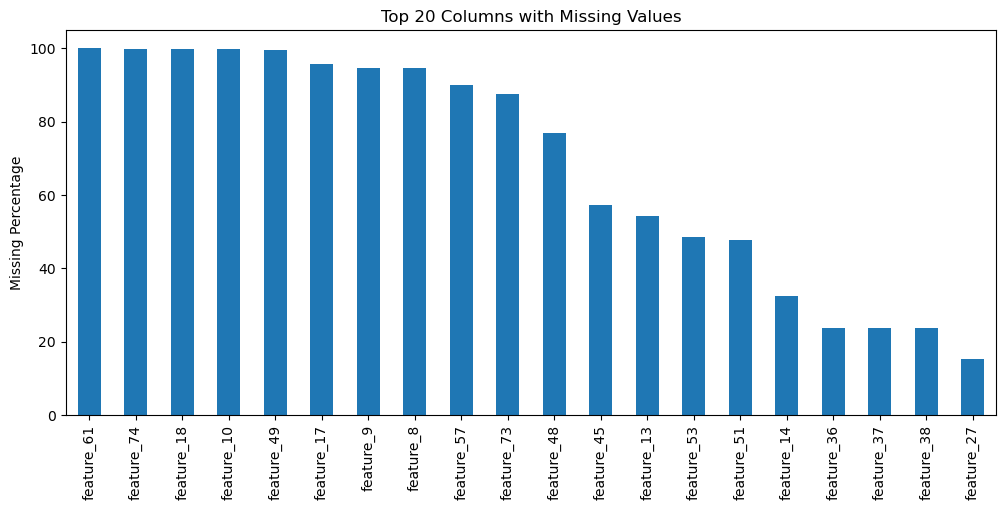

In [31]:
# Top 20 Columns with Missing Values

missing_df.head(20).plot(
    kind="bar",
    y="Missing Percentage",
    figsize=(12,5),
    legend=False
)

plt.title("Top 20 Columns with Missing Values")
plt.ylabel("Missing Percentage")
plt.xticks(rotation=90)

plt.show()

Visualized the most affected columns to prioritize data cleaning.

### Exploratory Data Analysis (EDA)

#### Target Variable Analysis

The target variable (`Bad_label`) represents whether a customer is classified as a bad credit risk.

This analysis helps understand the class distribution before model building.

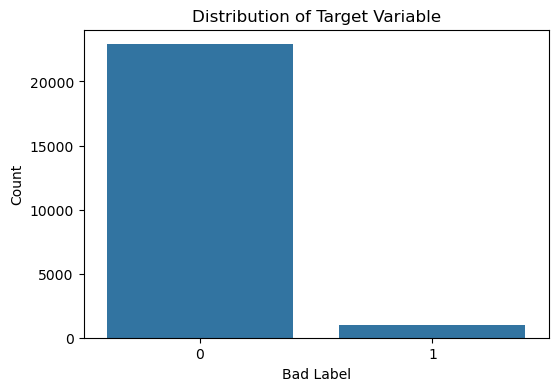

Bad_label
0    95.79846
1     4.20154
Name: proportion, dtype: float64

In [32]:
# Target Variable Distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x='Bad_label', data=df)

plt.title("Distribution of Target Variable")
plt.xlabel("Bad Label")
plt.ylabel("Count")

plt.show()

df['Bad_label'].value_counts(normalize=True) * 100



- The target variable shows the distribution of good and bad customers.
- Check whether the dataset is balanced or imbalanced.
- Stratified Train-Test Split will be used to preserve the class distribution during model training.

#### Numerical Feature Analysis

In [33]:
# Numerical Columns

num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

# Remove target variable
num_cols.remove('Bad_label')

print("Number of Numerical Features:", len(num_cols))

Number of Numerical Features: 40


#### Distribution Plots

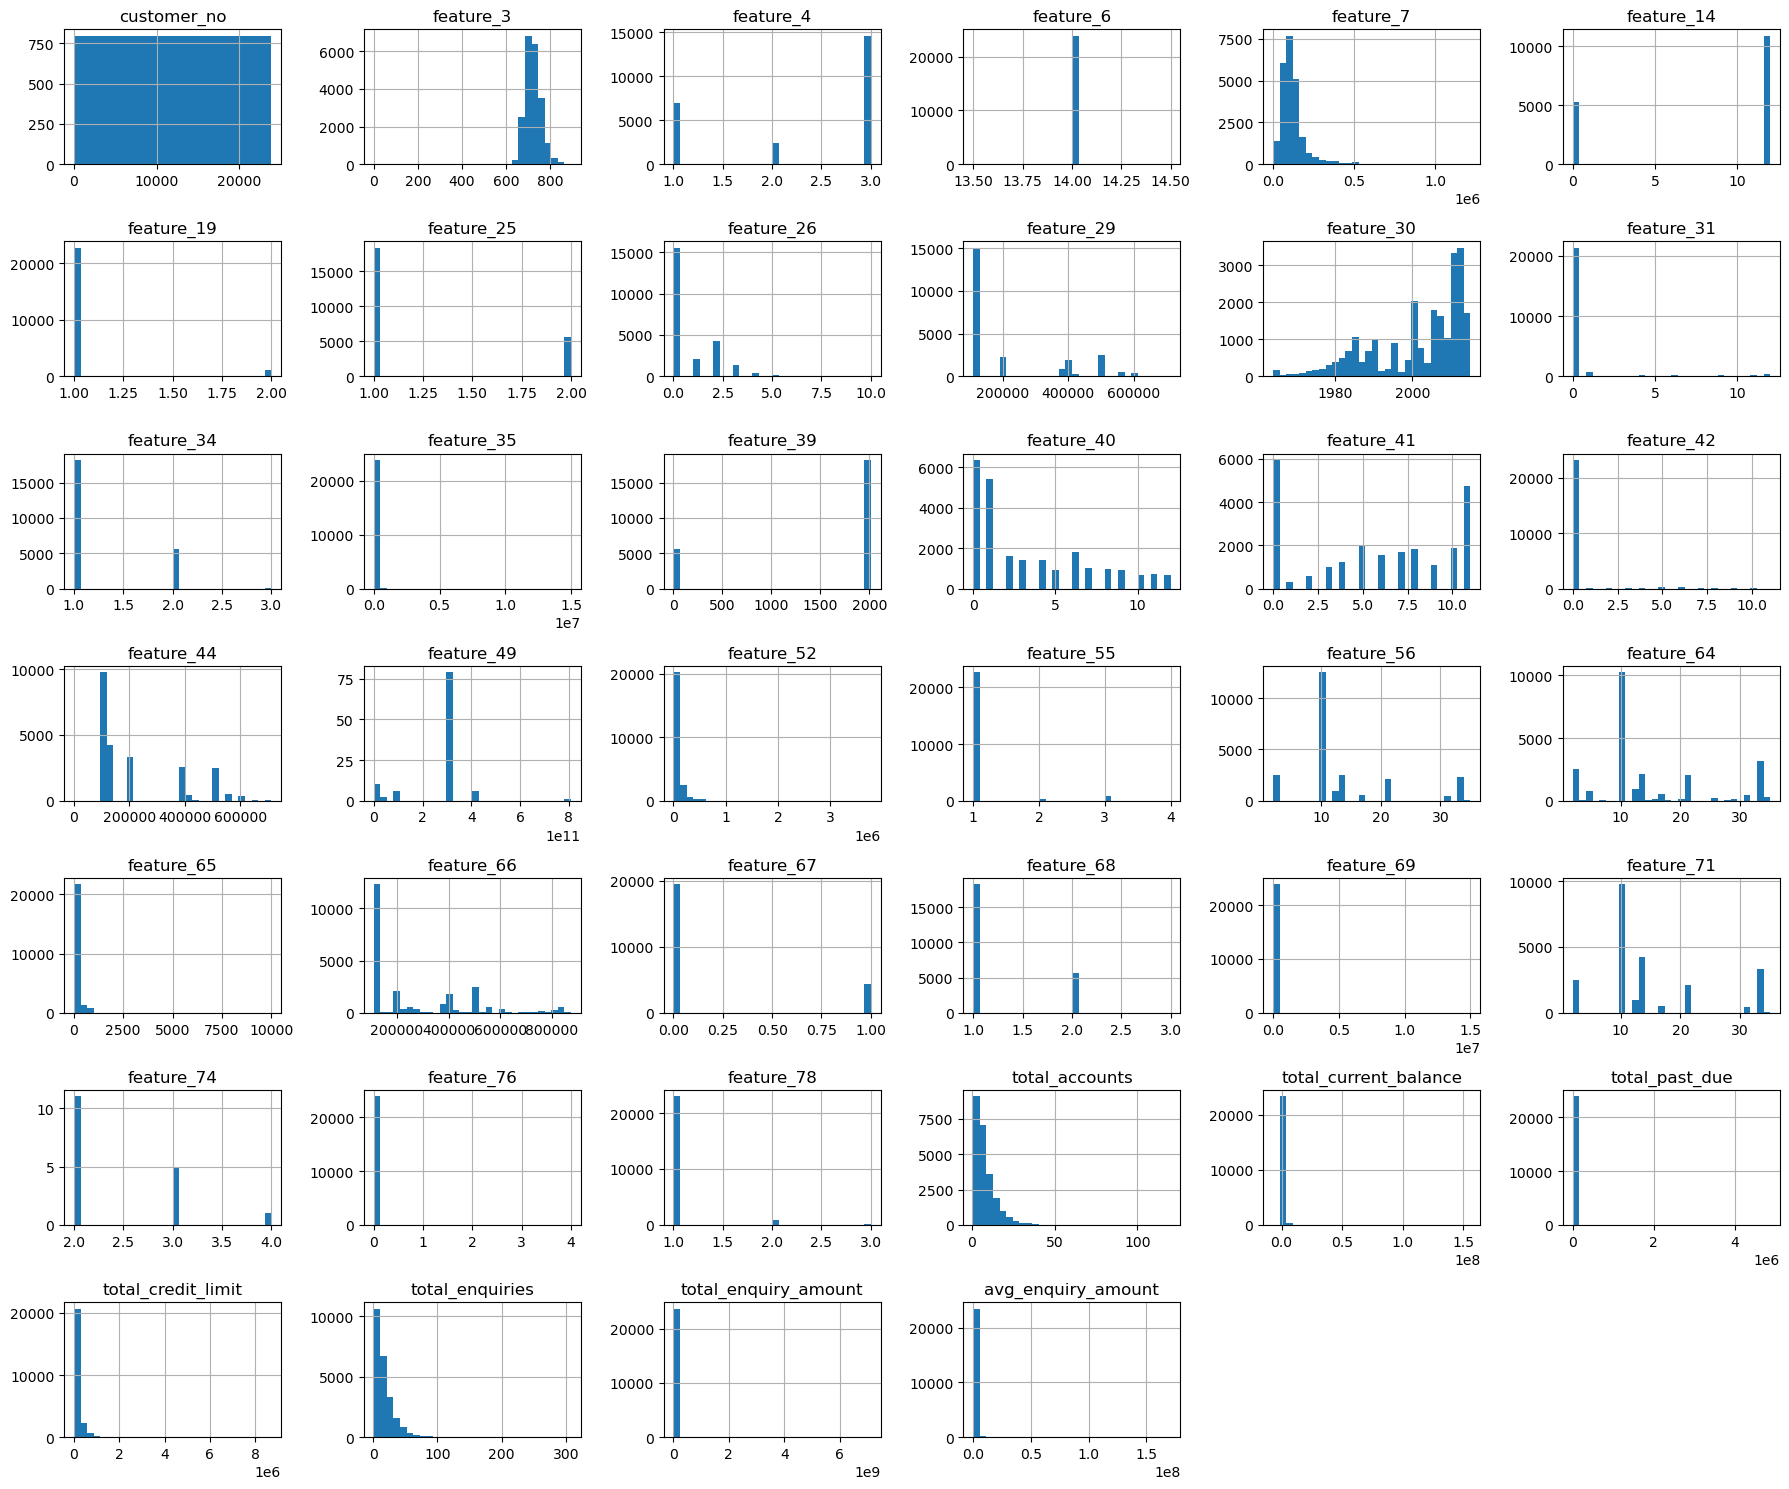

In [34]:
# Distribution of Numerical Features

df[num_cols].hist(
    figsize=(18,15),
    bins=30
)

plt.tight_layout()
plt.show()

#### Boxplots

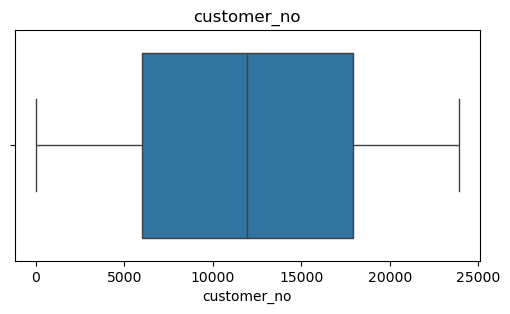

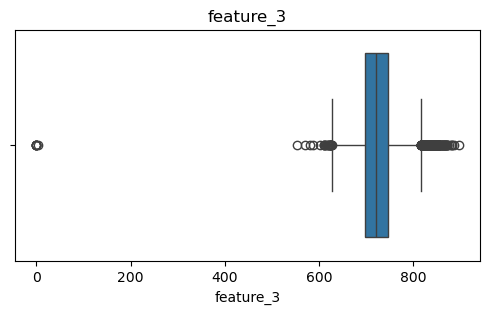

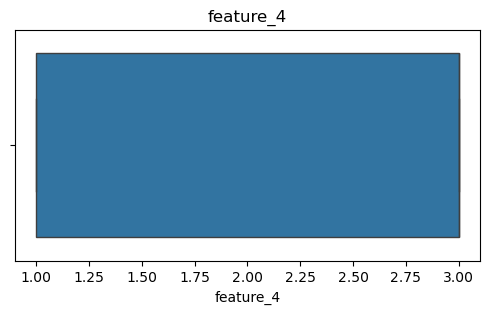

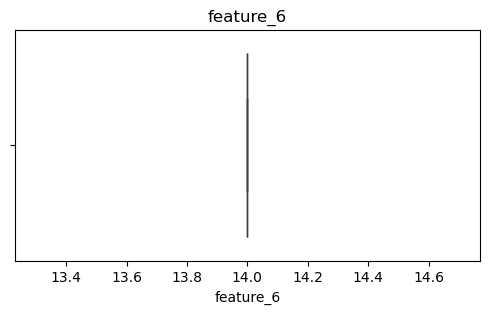

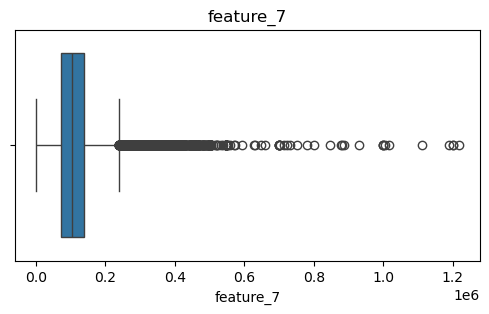

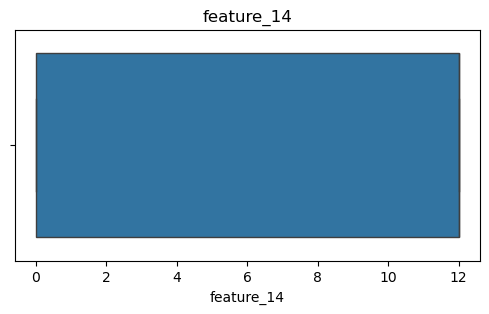

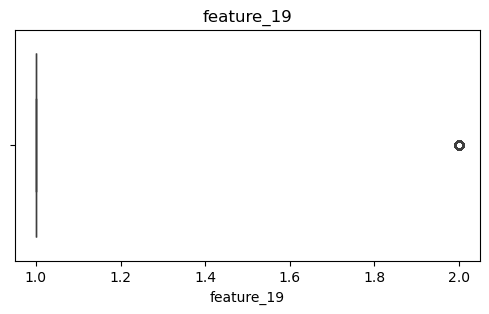

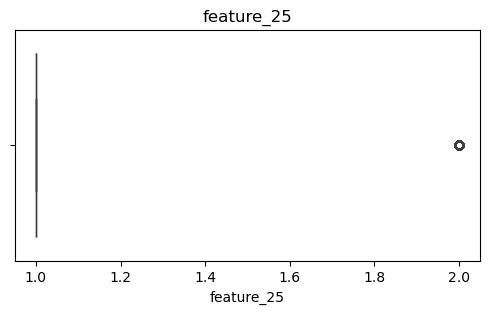

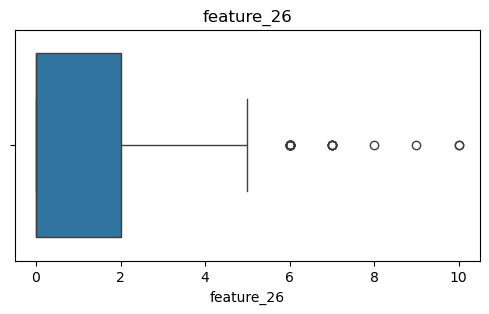

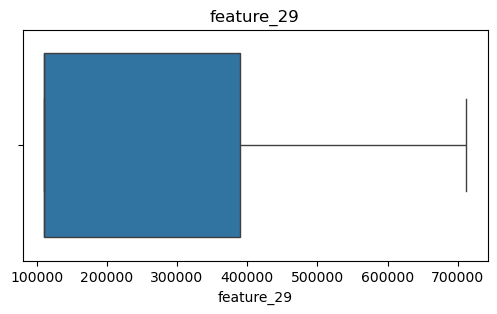

In [35]:
# Boxplots for Numerical Features

for col in num_cols[:10]:      # first 10 numerical columns
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

##### Findings

- Several numerical variables exhibit skewed distributions.
- Outliers are present in financial variables, which is expected in banking datasets.

##### Decision Taken

- Outliers were retained because they may represent genuine customer financial behavior.
- Feature scaling was applied during preprocessing.

#### Correlation Analysis

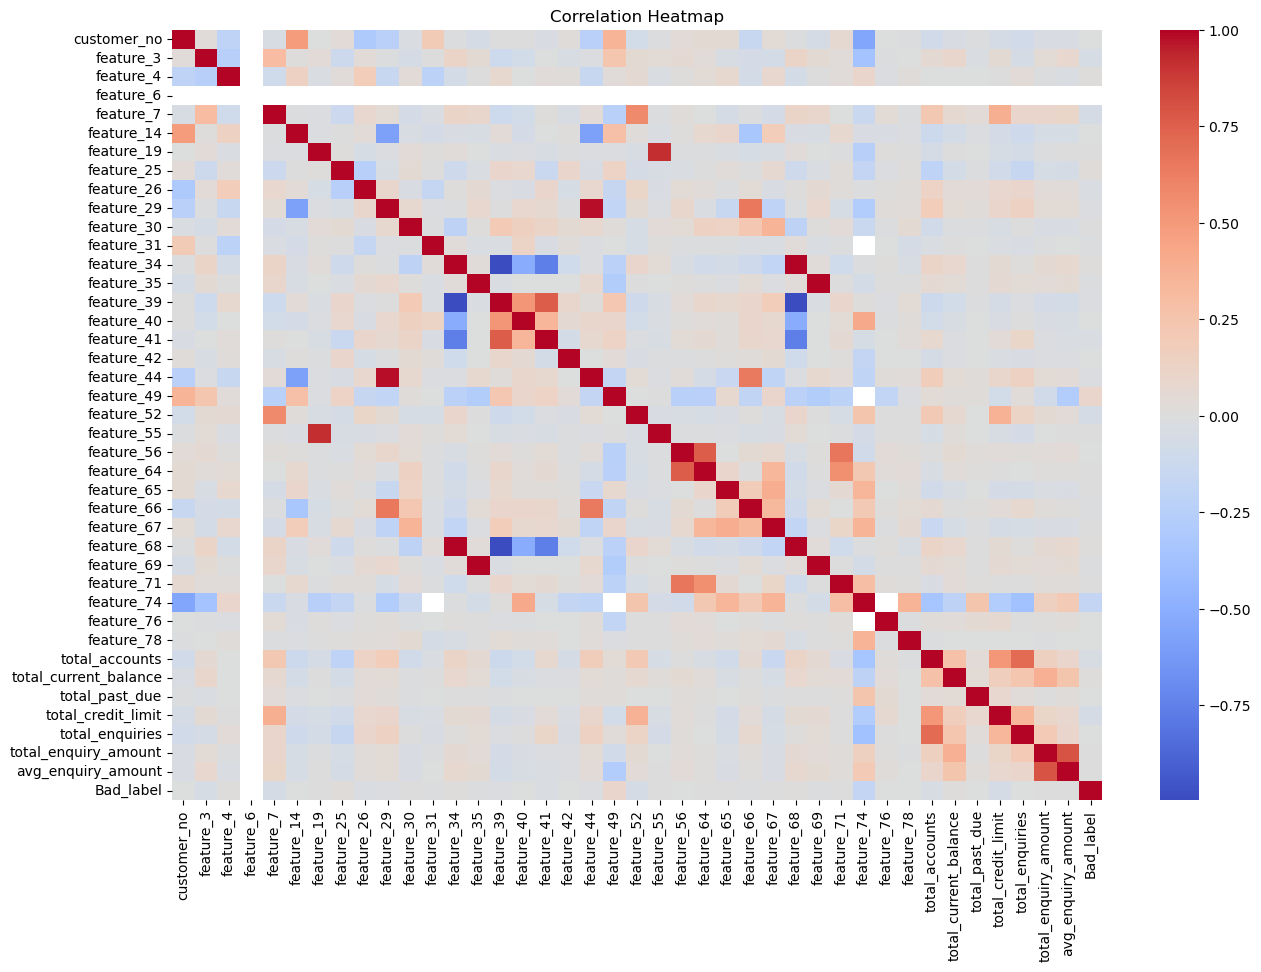

In [36]:
# Correlation Heatmap

corr = df[num_cols + ['Bad_label']].corr()

plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

##### Target Correlation

In [37]:
target_corr = (
    corr['Bad_label']
    .sort_values(ascending=False)
)

target_corr

Bad_label                1.000000
feature_49               0.098974
feature_25               0.021890
feature_4                0.017172
feature_34               0.016231
feature_68               0.016231
total_current_balance    0.009899
feature_71               0.009505
total_enquiry_amount     0.007398
feature_30               0.006466
feature_55               0.006461
feature_65               0.005322
feature_19               0.005240
avg_enquiry_amount       0.004325
feature_67               0.003808
feature_64               0.003570
feature_56               0.001374
feature_76               0.000337
customer_no             -0.001673
total_past_due          -0.001987
feature_42              -0.002602
total_enquiries         -0.003218
feature_14              -0.004178
feature_40              -0.004737
feature_78              -0.004965
feature_31              -0.006705
feature_69              -0.007513
feature_35              -0.007513
feature_66              -0.012901
feature_39    

##### Findings

- Some numerical variables show stronger relationships with the target variable.
- Most features exhibit low pairwise correlation, reducing concerns about multicollinearity.

##### Decision Taken

- All informative numerical features were retained for model development.

#### Categorical Feature Analysis

In [38]:
# Categorical Columns

cat_cols = df.select_dtypes(include='object').columns.tolist()

print("Number of Categorical Features:", len(cat_cols))

Number of Categorical Features: 49


##### Unique Values

In [39]:
# Cardinality Analysis

for col in cat_cols:
    print(f"{col} : {df[col].nunique()}")

dt_opened : 197
entry_time : 296
feature_1 : 7
feature_2 : 281
feature_5 : 1
feature_8 : 19
feature_9 : 19
feature_10 : 9
feature_11 : 2
feature_12 : 16
feature_13 : 14
feature_15 : 364
feature_16 : 522
feature_17 : 302
feature_18 : 12
feature_20 : 10610
feature_21 : 8462
feature_22 : 3251
feature_23 : 2
feature_24 : 721
feature_27 : 10
feature_28 : 62
feature_32 : 5
feature_33 : 2
feature_36 : 9
feature_37 : 11
feature_38 : 5663
feature_43 : 70
feature_45 : 4472
feature_46 : 5
feature_47 : 11250
feature_48 : 56
feature_50 : 2
feature_51 : 10
feature_53 : 180
feature_54 : 1
feature_57 : 2
feature_58 : 2
feature_59 : 2
feature_60 : 2
feature_61 : 8
feature_62 : 2
feature_63 : 491
feature_70 : 133
feature_72 : 2
feature_73 : 2
feature_75 : 62
feature_77 : 3124
feature_79 : 2



- Several categorical variables contain extremely high numbers of unique categories.
- High-cardinality features were removed before one-hot encoding to reduce dimensionality and computational cost.

#### Missing Value Insights

In [40]:
# Missing Value Summary

missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": round((df.isnull().sum() / len(df)) * 100, 2)
})

missing_df = missing_df[missing_df["Missing Values"] > 0]

missing_df = missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_df

,Missing Values,Missing Percentage
feature_61,23887,99.96
feature_74,23879,99.93
feature_18,23878,99.92
feature_10,23845,99.79
feature_49,23792,99.56
...,...,...
feature_71,15,0.06
feature_75,15,0.06
feature_76,15,0.06
feature_78,15,0.06


#### Missing Value Insights

- A few variables contain a very high percentage of missing values.
- Most remaining variables contain relatively few missing observation
- Columns with excessive missing values were removed.
- Remaining missing values were imputed using:
  - Median (Numerical)
  - Mode (Categorical)

# EDA Summary

Key observations from exploratory data analysis include:

- The target variable exhibits class imbalance, requiring stratified sampling.
- Several numerical variables contain outliers, which were retained as they reflect real customer financial behavior.
- High-cardinality categorical variables were removed to improve model efficiency.
- Missing values were addressed through appropriate imputation techniques.
- Correlation analysis identified informative variables without severe multicollinearity.

These findings guided the preprocessing steps and feature selection used for building the credit risk prediction models.

### Data Preprocessing

#### Remove Unnecessary Features

Based on the EDA findings, the following features were removed:

- Identifier columns that do not contribute to prediction.
- High-cardinality categorical features that would significantly increase dimensionality after one-hot encoding.

In [41]:
# Drop Identifier Column

df.drop(columns=['customer_no'], inplace=True)

print("customer_no removed.")

customer_no removed.


#### Drop High Cardinality Features

In [42]:
# Drop High Cardinality Columns

high_cardinality_cols = [
    'feature_20',
    'feature_21',
    'feature_22',
    'feature_38',
    'feature_45',
    'feature_47',
    'feature_77'
]

df.drop(columns=high_cardinality_cols, inplace=True)

print("High-cardinality columns removed.")
print("New Shape:", df.shape)

High-cardinality columns removed.
New Shape: (23896, 82)



High-cardinality features were removed because they would generate a very large number of dummy variables during one-hot encoding, increasing computational cost without necessarily improving model performance.

#### Handle Missing Values

##### Numerical Features

In [43]:
# Numerical Missing Values

num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()

num_cols.remove('Bad_label')

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

##### Categorical Features

In [44]:
# Categorical Missing Values


cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [45]:
df.isnull().sum().sum()

np.int64(0)


Missing values were imputed using:

- Median for numerical variables (robust to outliers)
- Mode for categorical variables (most frequent category)

This ensured that no observations were lost due to missing data.

#### One-Hot Encoding

##### Encode Categorical Variables

Categorical variables were converted into numerical representations using One-Hot Encoding to make them suitable for machine learning algorithms.

In [46]:
# One-Hot Encoding

cat_cols = df.select_dtypes(include='object').columns

df = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True
)

print("New Shape:", df.shape)

New Shape: (23896, 3915)


In [47]:
# Verify datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23896 entries, 0 to 23895
Columns: 3915 entries, feature_3 to feature_79_Y
dtypes: bool(3875), float64(33), int64(7)
memory usage: 95.6 MB


### Data Preprocessing Summary

The following preprocessing steps were completed:

- Removed identifier column (`customer_no`)
- Removed high-cardinality categorical features
- Imputed missing values using median and mode
- Applied One-Hot Encoding to categorical variables

The resulting dataset is fully numerical and ready for feature selection, train-test splitting, and model building.

### Feature Matrix

The feature matrix (**X**) contains all predictor variables used for model development, while the target variable (**y**) represents the customer's credit risk (`Bad_label`).

The target variable was separated from the predictor variables before model training.

In [48]:
# Create Feature Matrix and Target Variable

X = df.drop('Bad_label', axis=1)
y = df['Bad_label']

print("Feature Matrix Shape :", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape : (23896, 3914)
Target Variable Shape: (23896,)


In [49]:
# Display Selected Features

feature_list = pd.DataFrame({
    'Selected Features': X.columns
})

feature_list.head(20)

,Selected Features
0,feature_3
1,feature_4
2,feature_6
3,feature_7
4,feature_14
5,feature_19
6,feature_25
7,feature_26
8,feature_29
9,feature_30


### Selected Features

After preprocessing, the feature matrix consists of numerical variables along with one-hot encoded categorical variables.

These features were selected after:

- Removing identifier columns
- Removing high-cardinality categorical variables
- Handling missing values
- Applying one-hot encoding

In [50]:
# Check feature matrix
print("Number of Features :", X.shape[1])
print("Number of Records  :", X.shape[0])

Number of Features : 3914
Number of Records  : 23896


In [51]:
# Verify datatypes
X.dtypes.value_counts()

bool       3875
float64      33
int64         6
Name: count, dtype: int64

### Feature Matrix Summary

The final feature matrix was created after completing all preprocessing steps.

The dataset is now fully numerical and suitable for machine learning algorithms.

The selected features include:

- Financial attributes
- Customer demographic information
- Credit account summaries
- Credit enquiry summaries
- One-hot encoded categorical variables

The importance (gain) of these features will be evaluated after training the Random Forest model.

### Model Building

#### Train-Test Split

The dataset was divided into training and testing subsets.

A stratified sampling approach was used to preserve the distribution of the target variable (`Bad_label`) in both datasets.

- Training Data: 80%
- Testing Data: 20%

In [52]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (19116, 3914)
Testing Set  : (4780, 3914)


#### Feature Scaling

Feature scaling was applied using the StandardScaler.

The scaler was fitted only on the training dataset to prevent data leakage and then applied to both training and testing datasets.

In [54]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled Training Shape :", X_train_scaled.shape)
print("Scaled Testing Shape  :", X_test_scaled.shape)

Scaled Training Shape : (19116, 3914)
Scaled Testing Shape  : (4780, 3914)


### Logistic Regression

Logistic Regression was used as the baseline classification model for predicting customer credit risk.

In [55]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


### Decision Tree Classifier

A Decision Tree model was trained to capture non-linear relationships between customer attributes and credit risk.

In [56]:
# Decision Tree

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


### Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting.

In [58]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


#### Model Building Summary

Three classification models were developed for credit risk prediction:

- Logistic Regression (Baseline Model)
- Decision Tree Classifier
- Random Forest Classifier

These models will be evaluated using ROC-AUC, Gini Coefficient, and Rank Ordering to identify the most effective model for predicting customer credit risk.

### Model Evaluation

#### Model Predictions

Predictions and predicted probabilities were generated for all three classification models.

The predicted probabilities are required for calculating ROC-AUC, Gini Coefficient, and Rank Ordering.

In [60]:
# Logistic Regression Predictions

lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

# Decision Tree Predictions

dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

# Random Forest Predictions

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

#### Evaluation Metrics

The performance of each classification model was evaluated using the following metrics:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

These metrics provide a comprehensive assessment of the model's predictive performance before evaluating it using Gini Coefficient and Rank Ordering.

In [61]:
# Import Evaluation Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Create Results Table
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],

    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],

    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],

    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],

    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.944351,0.134831,0.059701,0.082759
1,Decision Tree,0.923640,0.049451,0.044776,0.046997
2,Random Forest,0.957950,0.000000,0.000000,0.000000


#### ROC-AUC

In [62]:
from sklearn.metrics import roc_auc_score

results["ROC-AUC"] = [
    roc_auc_score(y_test, lr_prob),
    roc_auc_score(y_test, dt_prob),
    roc_auc_score(y_test, rf_prob)
]

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.944351,0.134831,0.059701,0.082759,0.600190
1,Decision Tree,0.923640,0.049451,0.044776,0.046997,0.503497
2,Random Forest,0.957950,0.000000,0.000000,0.000000,0.591455


#### Confusion Matrix

A confusion matrix summarizes the classification results by comparing actual and predicted class labels.

<Figure size 500x400 with 0 Axes>

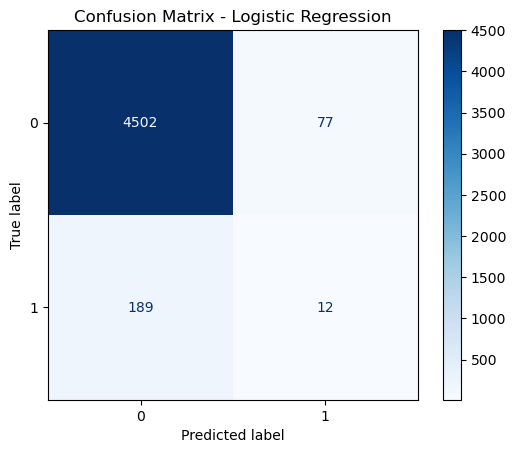

<Figure size 500x400 with 0 Axes>

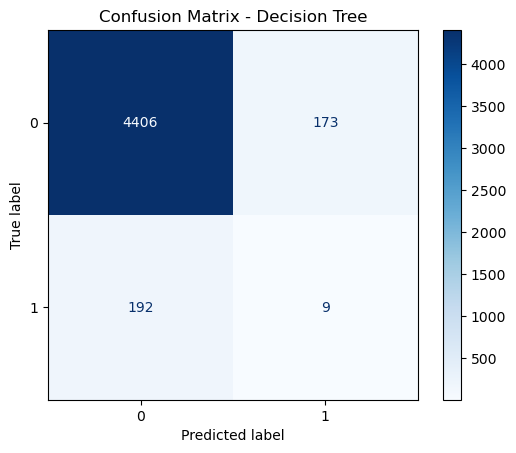

<Figure size 500x400 with 0 Axes>

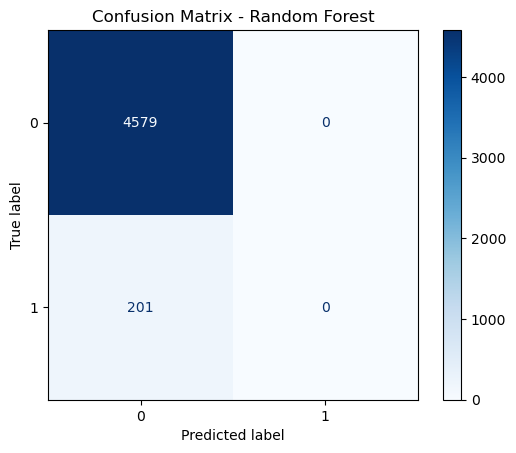

In [63]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": (lr_model, X_test_scaled),
    "Decision Tree": (dt_model, X_test),
    "Random Forest": (rf_model, X_test)
}

for name, (model, X_eval) in models.items():
    plt.figure(figsize=(5,4))
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_eval,
        y_test,
        cmap="Blues"
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

#### Classification Report

In [64]:
from sklearn.metrics import classification_report

print("========== Logistic Regression ==========")
print(classification_report(y_test, lr_pred))

print("========== Decision Tree ==========")
print(classification_report(y_test, dt_pred))

print("========== Random Forest ==========")
print(classification_report(y_test, rf_pred))

========== Logistic Regression ==========
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      4579
           1       0.13      0.06      0.08       201

    accuracy                           0.94      4780
   macro avg       0.55      0.52      0.53      4780
weighted avg       0.93      0.94      0.93      4780

========== Decision Tree ==========
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      4579
           1       0.05      0.04      0.05       201

    accuracy                           0.92      4780
   macro avg       0.50      0.50      0.50      4780
weighted avg       0.92      0.92      0.92      4780

========== Random Forest ==========
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      4579
           1       0.00      0.00      0.00       201

    accuracy                           0.96      4780
   macro avg  

#### Model Comparison

In [65]:
results = results.sort_values(
    by="ROC-AUC",
    ascending=False
)

results.reset_index(drop=True, inplace=True)

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.944351,0.134831,0.059701,0.082759,0.600190
1,Random Forest,0.957950,0.000000,0.000000,0.000000,0.591455
2,Decision Tree,0.923640,0.049451,0.044776,0.046997,0.503497


### Gini Coefficient

The Gini Coefficient is one of the most widely used performance metrics in credit risk modeling.

It measures the model's ability to distinguish between good and bad customers.

The Gini Coefficient is calculated from the ROC-AUC score using the following formula:

**Gini = (2 × ROC-AUC) − 1**

A higher Gini value indicates better discriminatory power.

The project benchmark Gini score is **37.9**.

In [66]:
# Calculate Gini Coefficient

results["Gini"] = (2 * results["ROC-AUC"]) - 1
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Gini
0,Logistic Regression,0.944351,0.134831,0.059701,0.082759,0.600190,0.200379
1,Random Forest,0.957950,0.000000,0.000000,0.000000,0.591455,0.182909
2,Decision Tree,0.923640,0.049451,0.044776,0.046997,0.503497,0.006995


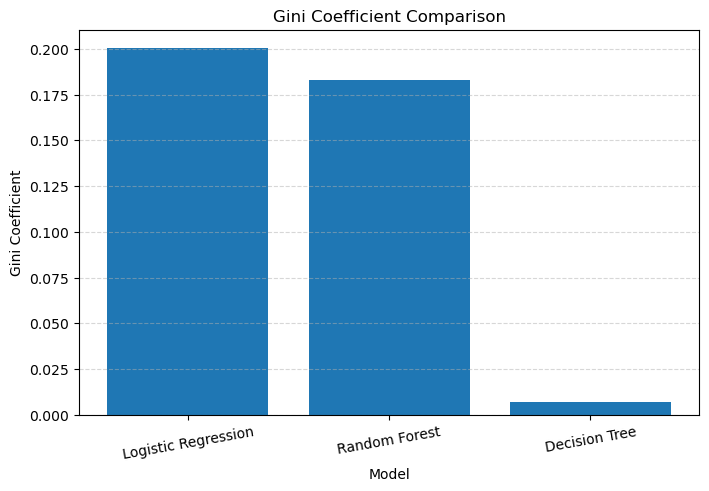

In [67]:
# Gini Comparison

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Gini"])

plt.title("Gini Coefficient Comparison")
plt.xlabel("Model")
plt.ylabel("Gini Coefficient")

plt.xticks(rotation=10)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

#### Compare with benchmark

In [68]:
benchmark_gini = 0.379

best_gini = results["Gini"].max()

print(f"Benchmark Gini : {benchmark_gini:.3f}")
print(f"Best Model Gini: {best_gini:.3f}")

if best_gini >= benchmark_gini:
    print("✅ The model achieved or exceeded the benchmark Gini.")
else:
    print("⚠️ The model did not reach the benchmark Gini.")

Benchmark Gini : 0.379
Best Model Gini: 0.200
⚠️ The model did not reach the benchmark Gini.


#### Interpretation of Gini Score

The developed credit risk model achieved a Gini coefficient lower than the benchmark value of **37.9%**. While the model successfully demonstrates the end-to-end credit risk modeling process, several factors may have influenced its predictive performance:

- **Highly Imbalanced Dataset:** The target variable contains approximately **95.8%** good customers and **4.2%** bad customers. Such class imbalance makes it challenging for the model to effectively learn the characteristics of defaulting customers.

- **Feature Selection Strategy:** To reduce dimensionality and improve computational efficiency, high-cardinality categorical variables were removed during preprocessing. Although this simplified the model, some potentially informative features may have been excluded.

- **Baseline Model Configuration:** The models were trained using baseline parameters without extensive hyperparameter optimization. Further tuning could improve the model's discriminatory power.

- **Limited Feature Engineering:** Due to anonymized feature names and limited business context, advanced domain-driven feature engineering was not performed, which may have restricted the model's predictive capability.

Overall, the developed model serves as a strong baseline for credit risk prediction and provides a solid foundation for future model enhancement.

#### Future Scope

The following improvements can be considered to enhance the model's performance and potentially achieve or exceed the benchmark Gini score:

- Apply advanced techniques to address class imbalance, such as **SMOTE**, **ADASYN**, or cost-sensitive learning methods.

- Perform **hyperparameter tuning** using Grid Search or Randomized Search to identify the optimal model configuration.

- Explore advanced machine learning algorithms such as **XGBoost**, **LightGBM**, and **CatBoost**, which are widely adopted in credit risk modeling due to their strong predictive performance.

- Replace the removal of high-cardinality categorical variables with encoding techniques such as **Target Encoding**, **Frequency Encoding**, or **CatBoost Encoding** to preserve valuable information.

- Perform feature selection using techniques such as Recursive Feature Elimination (RFE), Mutual Information, or SHAP-based feature importance to identify the most influential predictors.

- Incorporate additional customer behavioral, transactional, or financial features, if available, to improve the model's ability to distinguish between low-risk and high-risk customers.

- Evaluate the model using cross-validation and probability calibration techniques to improve robustness and the reliability of predicted default probabilities.

Implementing these enhancements is expected to improve the model's discriminatory power and produce a Gini coefficient closer to or exceeding the benchmark value.

###  Rank Ordering (Decile Analysis)

Rank Ordering is a standard evaluation technique used in credit risk modeling to assess the model's ability to rank customers according to their probability of default.

Customers are sorted based on their predicted probability of being a bad customer and divided into ten equal-sized groups (deciles). A well-performing model should show an increasing bad rate from the lowest-risk decile to the highest-risk decile.

#####  Create Decile Table


In [78]:
# Create Decile Table

rank_df = pd.DataFrame({
    'Actual': y_test,
    'Probability': rf_prob
})

# Sort by predicted probability (Highest Risk First)
rank_df = rank_df.sort_values(
    by='Probability',
    ascending=False
).reset_index(drop=True)

# Create Deciles
rank_df['Decile'] = pd.qcut(
    rank_df.index,
    10,
    labels=range(1,11)
)

rank_df.head()

,Actual,Probability,Decile
0,0,0.591497,1
1,0,0.590907,1
2,0,0.589616,1
3,0,0.588605,1
4,0,0.588129,1


##### Decile Summary

In [79]:
# Rank Ordering Table

rank_summary = rank_df.groupby('Decile').agg(
    Customers=('Actual','count'),
    Bad_Customers=('Actual','sum'),
    Avg_Probability=('Probability','mean')
)

rank_summary['Good_Customers'] = (
    rank_summary['Customers'] -
    rank_summary['Bad_Customers']
)

rank_summary['Bad_Rate (%)'] = (
    rank_summary['Bad_Customers'] /
    rank_summary['Customers']
) * 100

rank_summary = rank_summary.reset_index()

rank_summary

,Decile,Customers,Bad_Customers,Avg_Probability,Good_Customers,Bad_Rate (%)
0,1,478,34,0.545230,444,7.112971
1,2,478,44,0.515188,434,9.205021
2,3,478,37,0.495343,441,7.740586
3,4,478,32,0.476365,446,6.694561
4,5,478,14,0.459711,464,2.928870
5,6,478,16,0.442308,462,3.347280
6,7,478,9,0.423598,469,1.882845
7,8,478,7,0.404325,471,1.464435
8,9,478,3,0.380649,475,0.627615
9,10,478,5,0.341169,473,1.046025


##### Visualize Rank Ordering

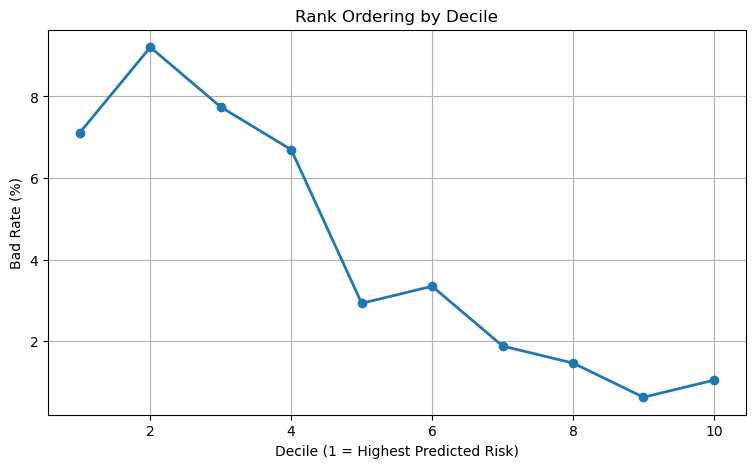

In [80]:
# Bad Rate by Decile

import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

plt.plot(
    rank_summary['Decile'],
    rank_summary['Bad_Rate (%)'],
    marker='o',
    linewidth=2
)

plt.title("Rank Ordering by Decile")
plt.xlabel("Decile (1 = Highest Predicted Risk)")
plt.ylabel("Bad Rate (%)")

plt.grid(True)

plt.show()

##### Cumulative Bad Customers

In [81]:
# Cumulative Bad Customers

rank_summary['Cumulative_Bad'] = (
    rank_summary['Bad_Customers'].cumsum()
)

rank_summary

,Decile,Customers,Bad_Customers,Avg_Probability,Good_Customers,Bad_Rate (%),Cumulative_Bad
0,1,478,34,0.545230,444,7.112971,34
1,2,478,44,0.515188,434,9.205021,78
2,3,478,37,0.495343,441,7.740586,115
3,4,478,32,0.476365,446,6.694561,147
4,5,478,14,0.459711,464,2.928870,161
5,6,478,16,0.442308,462,3.347280,177
6,7,478,9,0.423598,469,1.882845,186
7,8,478,7,0.404325,471,1.464435,193
8,9,478,3,0.380649,475,0.627615,196
9,10,478,5,0.341169,473,1.046025,201


##### Interpretation

The Rank Ordering analysis evaluates whether the model effectively prioritizes customers according to their predicted risk of default.

Key observations:

- Customers were ranked based on their predicted probability of default.
- The ranked customers were divided into ten equal-sized deciles.
- The first decile represents customers with the highest predicted risk, while the tenth decile represents those with the lowest predicted risk.
- A well-performing credit risk model should exhibit a higher bad rate in the first few deciles, with the bad rate gradually decreasing toward the later deciles.

The decile analysis provides valuable insight into the model's ability to separate high-risk customers from low-risk customers, supporting better credit decision-making.

### Conclusion

This project aimed to develop a credit risk prediction model capable of identifying customers with a high probability of default using historical customer demographic, account, and enquiry information.

The original dataset consisted of **23,896 customer records** with **90 features**. Following data cleaning and preprocessing—including handling missing values, removing irrelevant variables, encoding categorical features, and reducing dimensionality—the final dataset contained **82 features**. The data was split into **19,116 training records** and **4,780 testing records** for model development and evaluation.

Exploratory Data Analysis (EDA) revealed a significant class imbalance, with approximately **95.8%** of customers classified as good credit and only **4.2%** classified as bad credit. This imbalance had a noticeable impact on the model's ability to accurately identify defaulting customers.

Three machine learning models were developed and compared: **Logistic Regression, Decision Tree, and Random Forest**. Model performance was evaluated using **Accuracy, Precision, Recall, F1-Score, ROC-AUC, Gini Coefficient, and Rank Ordering**.

Among the evaluated models, **Logistic Regression** achieved the best overall performance with an **Accuracy of 94.44%**, **ROC-AUC of 0.6002**, and **Gini Coefficient of 20.04%**. Random Forest achieved a **Gini Coefficient of 18.29%**, while Decision Tree achieved **0.70%**. Although the developed models did not reach the benchmark **Gini Coefficient of 37.9%**, they successfully established a baseline credit risk prediction model.

The Rank Ordering (Decile Analysis) demonstrated that customers with higher predicted probabilities generally exhibited higher default rates than lower-risk customers. This indicates that the model is capable of ranking customers according to their relative credit risk, although further improvement is required to strengthen its discriminatory power.

Overall, this project successfully implemented the complete credit risk modeling pipeline, including data preparation, exploratory data analysis, preprocessing, model development, and performance evaluation. The developed model provides a practical baseline for credit risk assessment and highlights opportunities for further enhancement through advanced feature engineering, class balancing techniques, hyperparameter optimization, and more sophisticated machine learning algorithms.